In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, RocCurveDisplay


In [2]:
df = pd.read_csv("D:\\DS Assignment\\SVM\\SVM\\mushroom.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))
print(df['class'].value_counts(dropna=False))

print(df.isna().sum().sort_values(ascending=False).head(10))


Shape: (2000, 25)
Columns: ['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape', 'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring', 'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color', 'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat', 'class', 'stalk_height', 'cap_diameter']
  cap_shape cap_surface cap_color bruises   odor gill_attachment gill_spacing  \
0    sunken       scaly     white      no  anise      descending      distant   
1    sunken     fibrous       red      no  anise         notched      crowded   
2      flat     grooves    purple     yes   foul      descending      crowded   

  gill_size gill_color stalk_shape  ...  veil_type veil_color ring_number  \
0     broad       pink    tapering  ...    partial      brown         two   
1    narrow  chocolate   enlarging  ...  universal      brown         two   
2     broad    

Numeric cols: ['stalk_height', 'cap_diameter']
Categorical cols (first 10): ['cap_shape', 'cap_surface', 'cap_color', 'bruises', 'odor', 'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape']


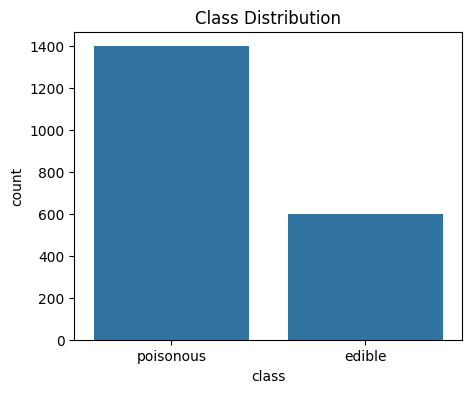

In [3]:
target_col = "class"
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in numeric_cols + [target_col]]

print("Numeric cols:", numeric_cols)
print("Categorical cols (first 10):", cat_cols[:10])

plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("Class Distribution")
plt.show()


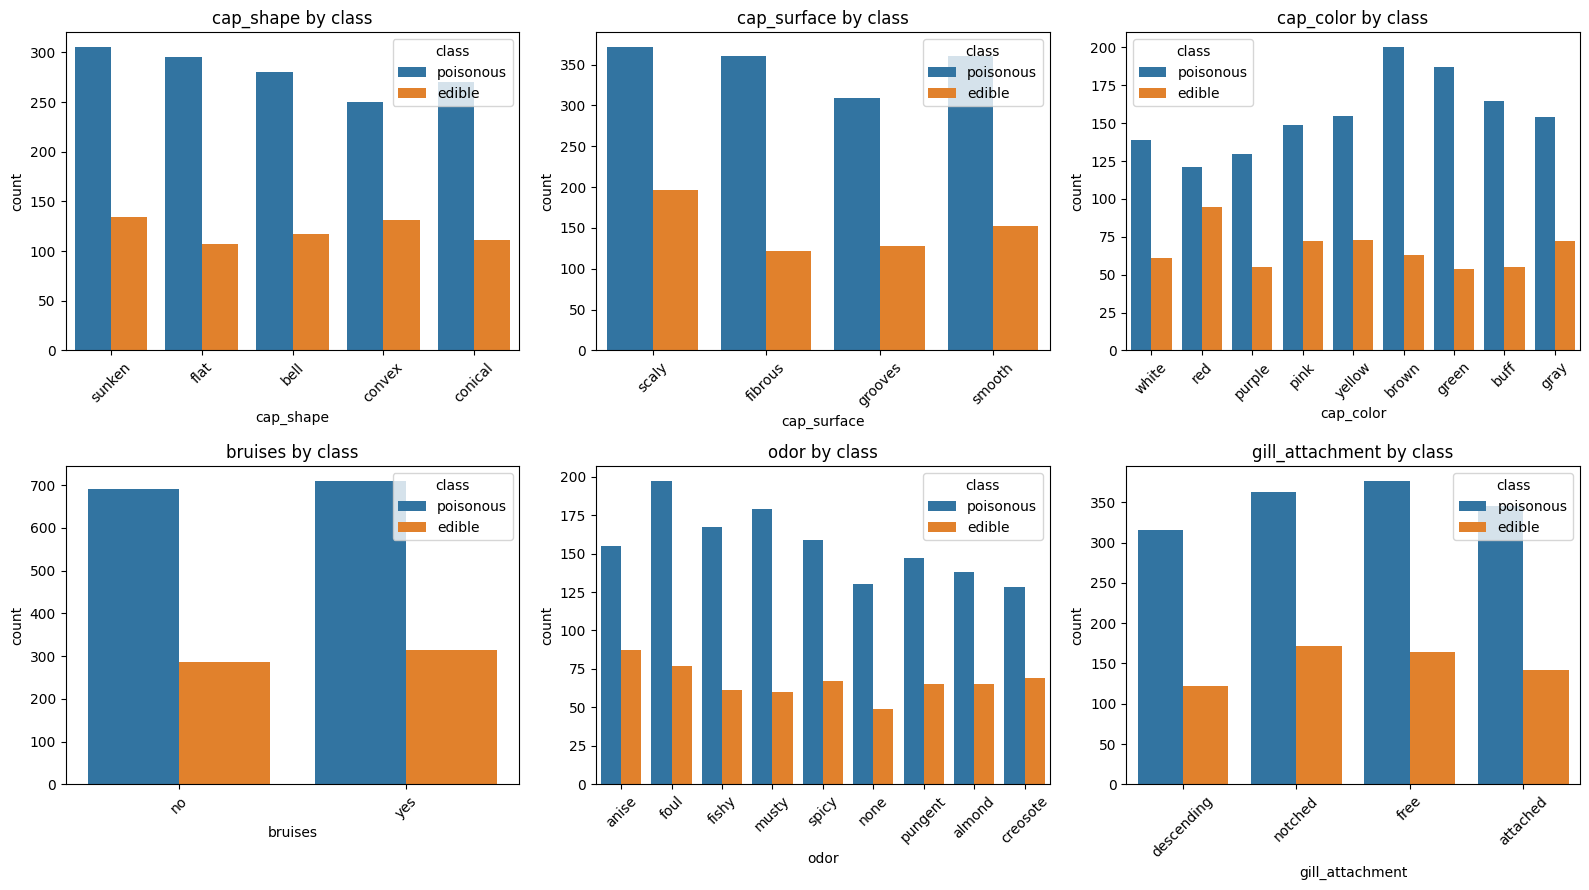

In [4]:
sample_cats = cat_cols[:6]  
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(sample_cats):
    sns.countplot(x=df[col], hue=df[target_col], ax=axes[i])
    axes[i].set_title(f"{col} by class")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


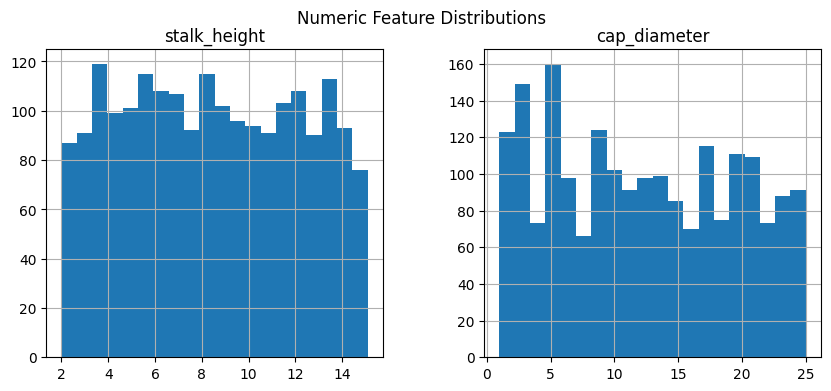

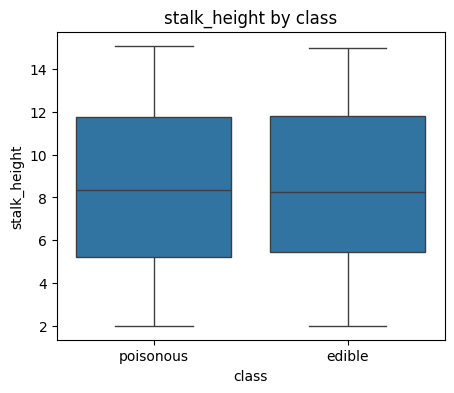

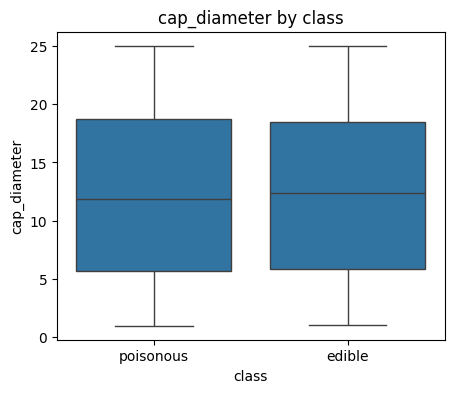

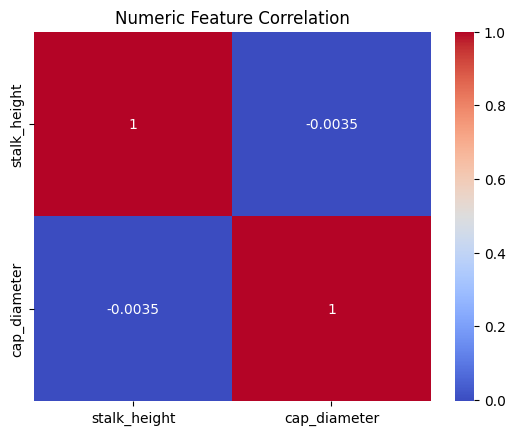

In [5]:
df[numeric_cols].hist(figsize=(10,4), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.show()

for col in numeric_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(f"{col} by class")
    plt.show()

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Numeric Feature Correlation")
    plt.show()


In [6]:
X = df.drop(columns=[target_col])
y = df[target_col].astype("category")

y = y.cat.rename_categories({"edible": 0, "poisonous": 1}).astype(int) if set(y.unique()) == set(["edible","poisonous"]) else y

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in numeric_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
svm_clf = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_clf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [8]:
y_pred = svm_clf.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))


Accuracy:  0.8075
Precision: 0.7875
Recall:    0.9929
F1-score:  0.8784

Classification report:

              precision    recall  f1-score   support

           0     0.9574    0.3750    0.5389       120
           1     0.7875    0.9929    0.8784       280

    accuracy                         0.8075       400
   macro avg     0.8725    0.6839    0.7086       400
weighted avg     0.8385    0.8075    0.7765       400



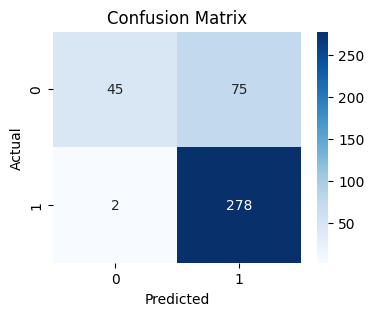

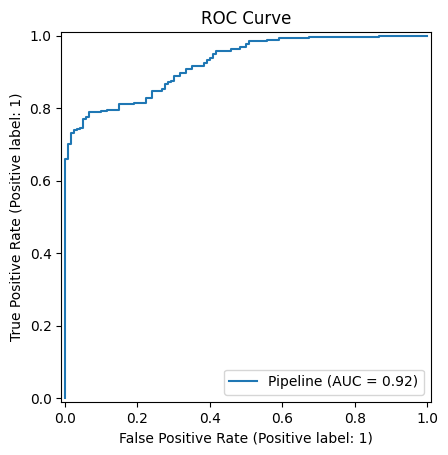

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

if hasattr(svm_clf.named_steps["clf"], "predict_proba"):
    RocCurveDisplay.from_estimator(svm_clf, X_test, y_test)
    plt.title("ROC Curve")
    plt.show()


###  SVM Decision Boundary Visualization

Since our dataset has many features (high-dimensional), we cannot directly visualize the decision boundary in 2D. To visualize how SVM separates the classes, we will select two numeric features (`stalk_height` and `cap_diameter`) and train a separate SVM model on just these two features.

This visualization shows the decision regions (background colors) and the data points.

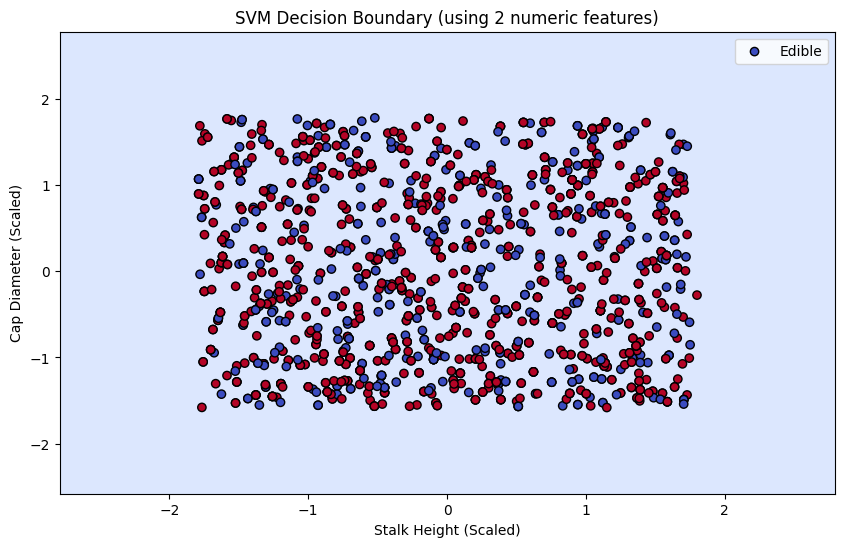

In [ ]:

X_vis = df[['stalk_height', 'cap_diameter']].copy()
y_vis = y.copy()


from sklearn.model_selection import train_test_split
X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=42
)


scaler = StandardScaler()
X_vis_train_scaled = scaler.fit_transform(X_vis_train)
X_vis_test_scaled = scaler.transform(X_vis_test)


svm_vis = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_vis.fit(X_vis_train_scaled, y_vis_train)


h = .02  
x_min, x_max = X_vis_train_scaled[:, 0].min() - 1, X_vis_train_scaled[:, 0].max() + 1
y_min, y_max = X_vis_train_scaled[:, 1].min() - 1, X_vis_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))


Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3) 
plt.scatter(X_vis_train_scaled[:, 0], X_vis_train_scaled[:, 1], 
            c=y_vis_train, cmap=plt.cm.coolwarm, edgecolors='k') 

plt.xlabel('Stalk Height (Scaled)')
plt.ylabel('Cap Diameter (Scaled)')
plt.title('SVM Decision Boundary (using 2 numeric features)')
plt.legend(['Edible', 'Poisonous'])
plt.show()

In [11]:
param_grid = [
    {"clf__kernel": ["linear"], "clf__C": [0.1, 1, 10]},
    {"clf__kernel": ["rbf"],    "clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.1, 0.01]},
    {"clf__kernel": ["poly"],   "clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.1], "clf__degree": [2, 3, 4]},
]

pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", SVC(probability=True, random_state=42))
])

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)
best_model = grid.best_estimator_


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'clf__C': 1, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}
Best CV F1: 0.9079496383290679


In [12]:
cv_res = pd.DataFrame(grid.cv_results_)
summary = (cv_res
           .assign(kernel=cv_res['param_clf__kernel'].astype(str))
           .groupby('kernel')['mean_test_score']
           .max()
           .sort_values(ascending=False))
print("Kernel-wise best mean CV F1:\n", summary)

y_pred_best = best_model.predict(X_test)
print("\nBest model test metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_best, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_best, zero_division=0))


Kernel-wise best mean CV F1:
 kernel
rbf       0.907950
poly      0.904852
linear    0.822661
Name: mean_test_score, dtype: float64

Best model test metrics:
Accuracy: 0.855
Precision: 0.8303571428571429
Recall: 0.9964285714285714
F1-score: 0.9058441558441559
